# Anatomy of a Flop — Error Analysis

## Scopul
Analizăm în profunzime erorile modelului câștigător — **Gradient Boosting**.

### Pași:
1. Distribuția reziduurilor
2. Predicted vs Actual
3. Heteroscedasticity check
4. Corelația erorilor cu variabilele independente
5. Filmele cel mai greșit prezise

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

df = pd.read_csv('../data/movies_clean.csv')

features = ['budget', 'vote_average', 'vote_count',
            'popularity', 'runtime', 'release_year', 'release_month']

X = df[features]
y = df['disappointment_index']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

residuals = y_test - y_pred

print(f" Model reantrenat — Gradient Boosting")
print(f"   R²   = {r2_score(y_test, y_pred):.4f}")
print(f"   RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

 Model reantrenat — Gradient Boosting
   R²   = 0.4939
   RMSE = 5.8106


## 1. Distribuția Reziduurilor

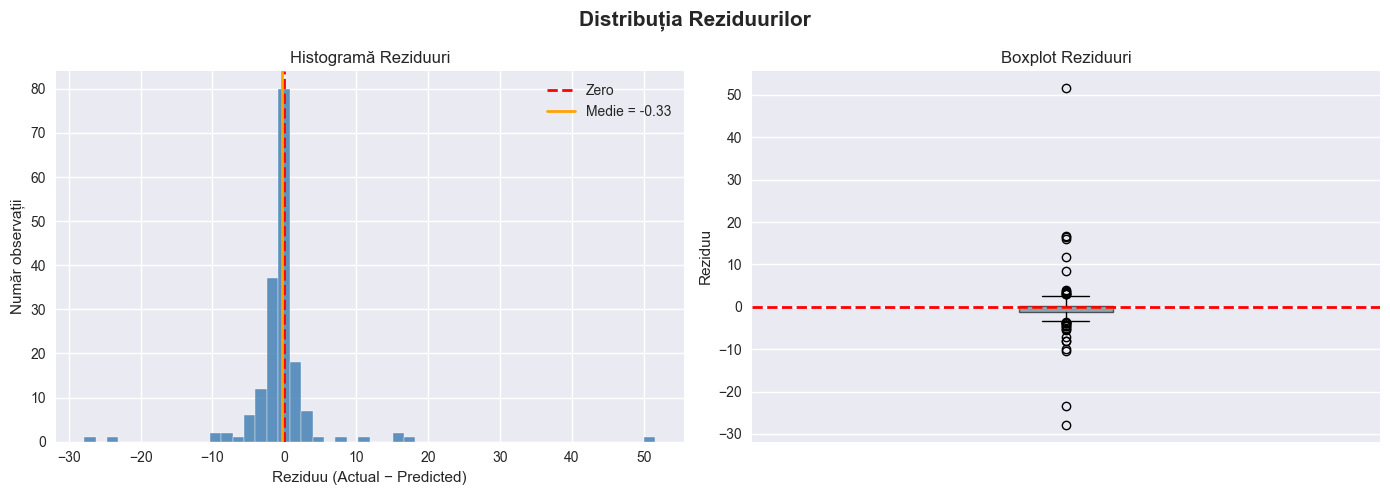

Statistici reziduuri:
   Medie:       -0.3277
   Mediană:     -0.5076
   Std:         5.8180
   Min:         -27.8552
   Max:         51.6156
   Erori < 2:   76.4% din cazuri


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuția Reziduurilor', fontsize=15, fontweight='bold')

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0].axvline(x=residuals.mean(), color='orange', linestyle='-',
                linewidth=2, label=f'Medie = {residuals.mean():.2f}')
axes[0].set_title('Histogramă Reziduuri')
axes[0].set_xlabel('Reziduu (Actual − Predicted)')
axes[0].set_ylabel('Număr observații')
axes[0].legend()

axes[1].boxplot(residuals, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Boxplot Reziduuri')
axes[1].set_ylabel('Reziduu')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data/residuals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Statistici reziduuri:")
print(f"   Medie:       {residuals.mean():.4f}")
print(f"   Mediană:     {residuals.median():.4f}")
print(f"   Std:         {residuals.std():.4f}")
print(f"   Min:         {residuals.min():.4f}")
print(f"   Max:         {residuals.max():.4f}")
print(f"   Erori < 2:   {(abs(residuals) < 2).mean()*100:.1f}% din cazuri")

### Interpretare — Distribuția Reziduurilor

- **Medie = −0.33** — aproape de 0, modelul nu are bias sistematic semnificativ
- **76.4% din erori sunt sub 2 unități DI** — pentru filmele obișnuite, predicțiile sunt bune
- **Distribuție asimetrică spre dreapta** — coada lungă pozitivă (vizibilă în histogramă) arată că subestimăm câteva surprize pozitive extreme
- **Boxplot:** cutia e concentrată în jurul lui 0, dar există outlieri clari — un film cu reziduu de +51.6 (Halloween) și câteva cu reziduuri negative mari (~−27)

**Concluzie:** Modelul funcționează bine pentru filmele tipice, dar subestimează sistematic filmele legendare cu bugete mici și venituri uriașe.

## 2. Predicted vs Actual

Graficul compară valorile prezise de model cu valorile reale ale Disappointment Index.
Linia roșie reprezintă predicția perfectă — cu cât punctele sunt mai aproape de ea, cu atât modelul prezice mai bine.

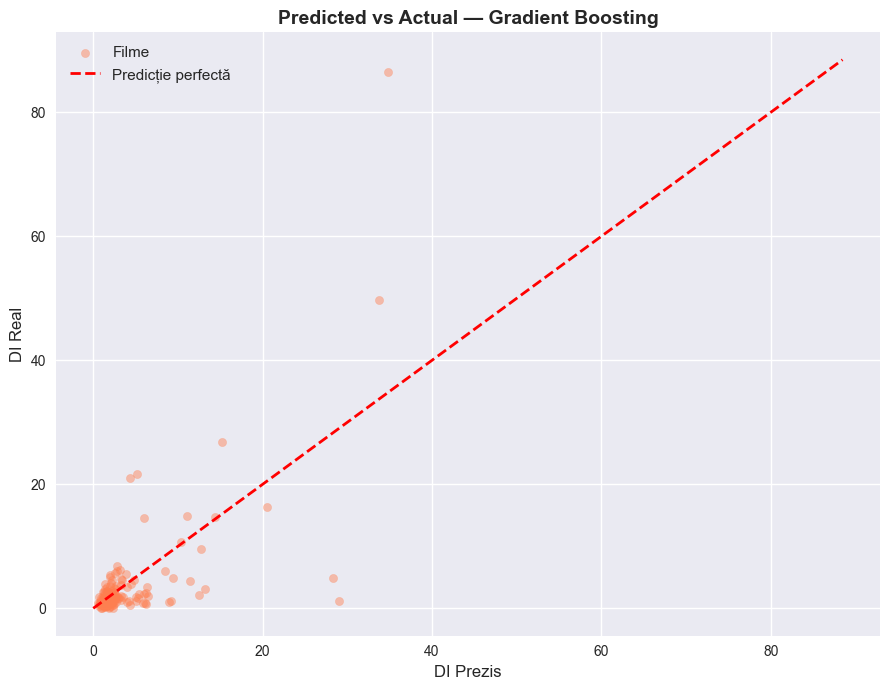

In [17]:
plt.figure(figsize=(9, 7))

plt.scatter(y_pred, y_test, alpha=0.45, color='coral', s=35, label='Filme')

lim = max(y_test.max(), y_pred.max()) + 2
plt.plot([0, lim], [0, lim], 'r--', linewidth=2, label='Predicție perfectă')

plt.title('Predicted vs Actual — Gradient Boosting', fontsize=14, fontweight='bold')
plt.xlabel('DI Prezis', fontsize=12)
plt.ylabel('DI Real', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretare — Predicted vs Actual

- **Masa de puncte din colțul stânga-jos** — majoritatea filmelor au DI mic (0−5) și sunt prezise corect, strânse lângă linia roșie
- **Punctele deasupra liniei** — modelul a subestimat aceste filme: realitatea a fost mult mai bună decât predicția (ex. Halloween cu DI real = 86, prezis ~35)
- **Niciun punct semnificativ sub linie** — modelul nu supraestimează, tinde mai degrabă să fie conservator
- **Cu cât DI real e mai mare, cu atât punctul e mai departe de linie** — filmele legendare sunt cele mai greu de prezis

**Concluzie:** Modelul prezice bine filmele obișnuite (DI 0−5), dar subestimează sistematic surprizele pozitive extreme — ceea ce e de așteptat, deoarece aceste filme au depășit orice precedent istoric.

## 3. Heteroscedasticity Check — Reziduuri vs Predicted


În contextul proiectului nostru, suspectăm că modelul greșește mai mult pentru filmele
cu DI mare decât pentru cele obișnuite.

Verificăm acest lucru în două moduri:
1. **Vizual** — grafice reziduuri vs predicted
2. **Statistic** — testul Breusch-Pagan

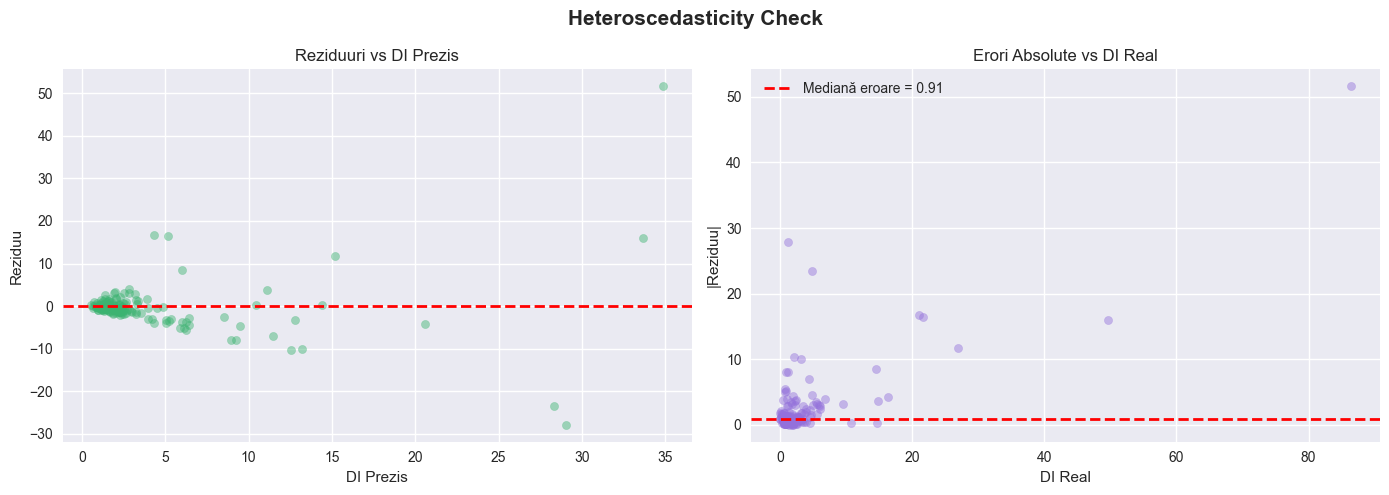

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Heteroscedasticity Check', fontsize=15, fontweight='bold')

axes[0].scatter(y_pred, residuals, alpha=0.45, color='mediumseagreen', s=35)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Reziduuri vs DI Prezis')
axes[0].set_xlabel('DI Prezis')
axes[0].set_ylabel('Reziduu')

axes[1].scatter(y_test, abs(residuals), alpha=0.45, color='mediumpurple', s=35)
axes[1].axhline(y=abs(residuals).median(), color='red', linestyle='--',
                linewidth=2, label=f'Mediană eroare = {abs(residuals).median():.2f}')
axes[1].set_title('Erori Absolute vs DI Real')
axes[1].set_xlabel('DI Real')
axes[1].set_ylabel('|Reziduu|')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/heteroscedasticity.png', dpi=150, bbox_inches='tight')
plt.show()


- Masa de puncte e concentrată lângă 0 pentru DI prezis mic → erori mici pentru filmele obișnuite
- Pe măsură ce DI prezis crește, erorile se împrăștie mai mult → formă de pâlnie
- Sugerează prezența heteroscedasticity

**Graficul dreapta — Erori Absolute vs DI Real:**
- Mediană eroare = 0.91 → jumătate din filme sunt prezise cu eroare sub 1 unitate DI
- Eroarea crește odată cu DI real → cu cât filmul a surprins mai mult, cu atât modelul greșește mai mult
- Punctul izolat (DI ~86) = Halloween

Analiza vizuală sugerează prezența heteroscedasticity. Confirmăm statistic prin testul Breusch-Pagan.

### Test Breusch-Pagan — Heteroscedasticity

In [12]:
import statsmodels.stats.diagnostic as diag
import statsmodels.api as sm

X_test_sm = sm.add_constant(X_test)

bp_test = diag.het_breuschpagan(residuals, X_test_sm)

print("Test Breusch-Pagan:")
print(f"   Statistică LM:  {bp_test[0]:.4f}")
print(f"   p-value:        {bp_test[1]:.4f}")
print(f"   F-statistică:   {bp_test[2]:.4f}")
print(f"   p-value (F):    {bp_test[3]:.4f}")

if bp_test[1] < 0.05:
    print("\np-value < 0.05 → Respingem H0 → Heteroscedasticity confirmată statistic")
else:
    print("\n p-value > 0.05 → Nu respingem H0 → Nu există heteroscedasticity semnificativă")

Test Breusch-Pagan:
   Statistică LM:  24.1692
   p-value:        0.0011
   F-statistică:   3.8254
   p-value (F):    0.0007

p-value < 0.05 → Respingem H0 → Heteroscedasticity confirmată statistic


### Test Breusch-Pagan — Ipoteze

- **H₀:** Varianța reziduurilor este constantă (homoscedasticity)
- **H₁:** Varianța reziduurilor depinde de variabilele independente (heteroscedasticity)
- **Prag de semnificație:** α = 0.05


p-value = 0.0011 < 0.05 → **Respingem H₀**

Heteroscedasticity este confirmată statistic — varianța reziduurilor
nu este constantă, ci depinde de variabilele independente.

Acest rezultat e consistent cu analiza vizuală și cu natura datelor:
modelul greșește mai mult pentru filmele cu DI mare (surprize extreme)
decât pentru filmele obișnuite. Heteroscedasticity nu invalidează modelul,
dar sugerează că predicțiile pentru blockbustere excepționale
trebuie interpretate cu mai multă precauție.

## 4. Corelația Erorilor cu Variabilele Independente

Verificăm dacă reziduurile sunt corelate cu variabilele independente.
Dacă o variabilă e corelată puternic cu erorile, înseamnă că modelul
nu a exploatat-o suficient.

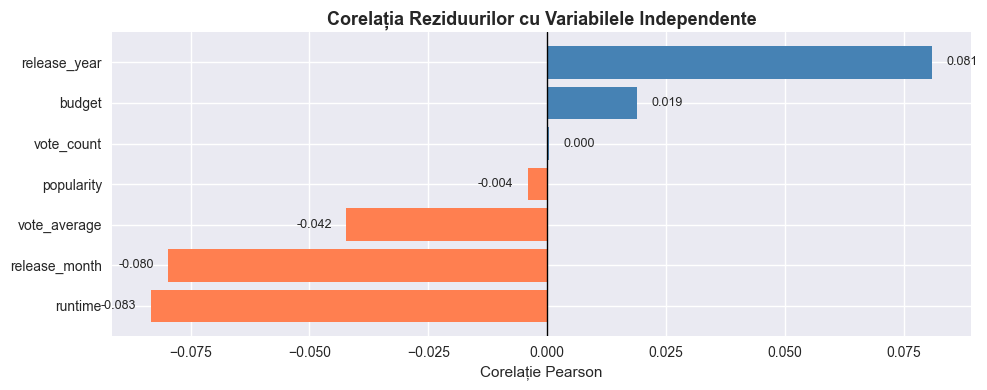

Corelații reziduu ~ features:
runtime         -0.083359
release_month   -0.079646
vote_average    -0.042232
popularity      -0.004077
vote_count       0.000365
budget           0.018938
release_year     0.080982


In [13]:
df_test = X_test.copy()
df_test['residual'] = residuals.values
df_test['abs_error'] = abs(residuals).values

corr_residuals = df_test[features + ['residual']].corr()['residual'].drop('residual').sort_values()

plt.figure(figsize=(10, 4))
colors = ['coral' if x < 0 else 'steelblue' for x in corr_residuals]
bars = plt.barh(corr_residuals.index, corr_residuals.values, color=colors)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Corelația Reziduurilor cu Variabilele Independente', fontsize=13, fontweight='bold')
plt.xlabel('Corelație Pearson')

for bar, val in zip(bars, corr_residuals.values):
    plt.text(val + (0.003 if val >= 0 else -0.003),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../data/residuals_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print("Corelații reziduu ~ features:")
print(corr_residuals.to_string())


**Rezultate:**
- release_year: +0.081 — corelație pozitivă mică
- budget: +0.019 — practic neglijabil
- vote_count: +0.000 — zero
- popularity: −0.004 — neglijabil
- vote_average: −0.042 — neglijabil
- release_month: −0.080 — corelație negativă mică
- runtime: −0.083 — corelație negativă mică

**Concluzie:**
Toate corelațiile sunt foarte aproape de 0 — nicio variabilă
nu e corelată semnificativ cu reziduurile. Asta înseamnă că
Gradient Boosting a exploatat bine informația din toate cele
7 features și nu a lăsat pattern-uri sistematice neextrase.

Singurele corelații ușor mai mari (release_year și runtime)
sunt sub pragul de 0.1 — insuficiente pentru a indica
o problemă reală de modelare.

## 5. Filmele Cel Mai Greșit Prezise

Identificăm filmele pentru care modelul a greșit cel mai mult
și încercăm să înțelegem de ce.

Top 10 filme cel mai greșit prezise:
                          title  actual_di  predicted_di  abs_error   budget  release_year
                      Halloween  86.474581     34.858992  51.615589   325000          1978
          It's a Wonderful Life   1.213097     29.068282  27.855185  3180000          1946
               The Wizard of Oz   4.862077     28.334232  23.472156  2777000          1939
                  Seven Samurai  21.000000      4.296033  16.703967  2000000          1954
                     Your Name.  21.617074      5.139770  16.477304  7500000          2016
Snow White and the Seven Dwarfs  49.697025     33.684952  16.012073  1488423          1938
                           Jaws  26.894457     15.209738  11.684719  7000000          1975
                       Superman   2.185298     12.539790  10.354492 55000000          1978
          The Godfather Part II   3.156923     13.227613  10.070690 13000000          1974
One Flew Over the Cuckoo's Nest  14.530837      6.000

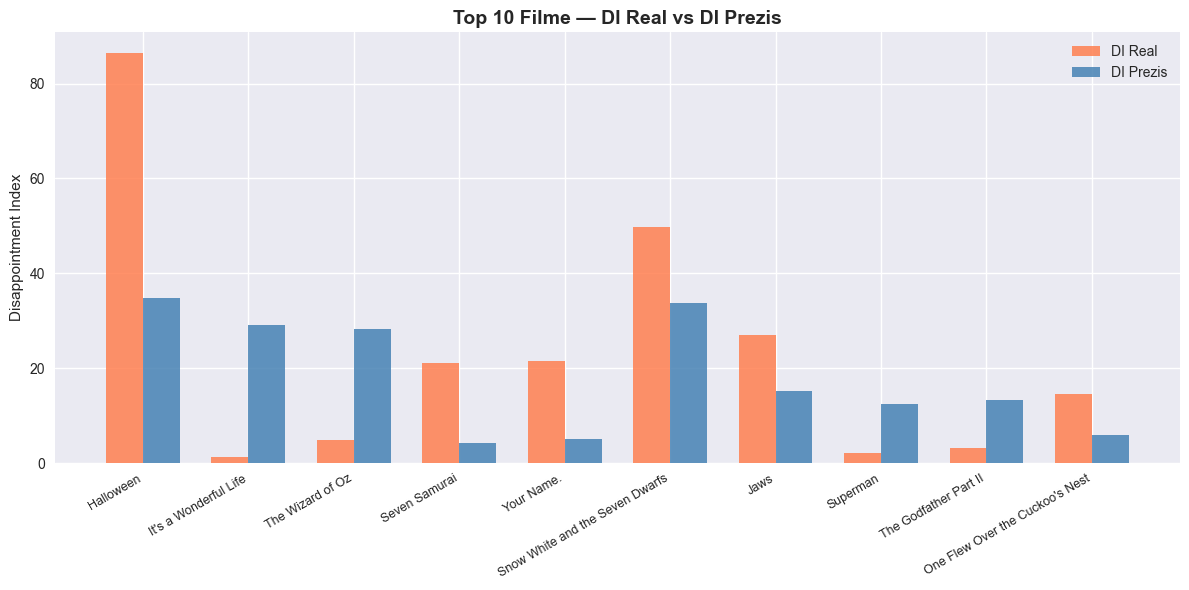

In [14]:
df_test['title'] = df.loc[X_test.index, 'title'].values
df_test['actual_di'] = y_test.values
df_test['predicted_di'] = y_pred

top_errors = df_test.nlargest(10, 'abs_error')[
    ['title', 'actual_di', 'predicted_di', 'abs_error', 'budget', 'release_year']
].reset_index(drop=True)

print("Top 10 filme cel mai greșit prezise:")
print(top_errors.to_string(index=False))

plt.figure(figsize=(12, 6))
x = range(len(top_errors))
width = 0.35

plt.bar([i - width/2 for i in x], top_errors['actual_di'],
        width, label='DI Real', color='coral', alpha=0.85)
plt.bar([i + width/2 for i in x], top_errors['predicted_di'],
        width, label='DI Prezis', color='steelblue', alpha=0.85)

plt.xticks(x, top_errors['title'], rotation=30, ha='right', fontsize=9)
plt.ylabel('Disappointment Index')
plt.title('Top 10 Filme — DI Real vs DI Prezis', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/top_errors.png', dpi=150, bbox_inches='tight')
plt.show()


**1. Halloween (1978) — eroare 51.6**
Budget: 325.000$ | DI real: 86.5 | DI prezis: 34.9
Filmat în 20 de zile cu actori necunoscuți, a devenit fondatorul
genului slasher și unul dintre cele mai profitabile filme independente
din istorie. Niciun model nu putea anticipa că un film de groază
cu buget minimal va redefini un gen întreg.

**2. It's a Wonderful Life (1946) — eroare 27.9**
Budget: 3.18M$ | DI real: 29.1 | DI prezis: 1.2
La lansare a fost considerat un eșec comercial și a intrat în domeniul
public. A devenit film de Crăciun cult abia după decenii, difuzat
la nesfârșit la televizor. Modelul judecă performanța la momentul
lansării — nu poate prezice posteritatea unui film.

**3. The Wizard of Oz (1939) — eroare 23.5**
Budget: 2.77M$ | DI real: 4.9 | DI prezis: 28.3
Produs în era de aur a Hollywood-ului, cu reguli complet diferite
ale industriei. Modelul antrenat pe date moderne nu poate extrapola
corect la contextul economic și cultural al anilor 1930.

**4. Seven Samurai (1954) — eroare 16.7**
Budget: 2M$ | DI real: 21.0 | DI prezis: 4.3
Capodopera lui Akira Kurosawa a fost produsă în Japonia postbelică
cu un budget considerabil pentru acea perioadă. A influențat
cinematografia mondială timp de decenii — un impact imposibil
de cuantificat la momentul lansării.

**5. Your Name (2016) — eroare 16.5**
Budget: 7.5M$ | DI real: 21.6 | DI prezis: 5.1
Animație japaneză independentă care a devenit un fenomen cultural
global, depășind toate estimările pentru un film de animație
non-Disney/Pixar. A demonstrat că publicul global poate fi captivat
de o poveste japaneză autentică — un precedent nou în industrie.

**6. Snow White and the Seven Dwarfs (1938) — eroare 12.1**
Budget: 1.49M$ | DI real: 49.7 | DI prezis: 16.0
Primul lungmetraj de animație din istorie. Industria îl numea
"Prostia lui Disney" înainte de lansare — nimeni nu credea că
publicul va sta 83 de minute să urmărească desene animate.
A devenit cel mai mare succes comercial al anului 1938.

**7. Jaws (1975) — eroare 11.7**
Budget: 7M$ | DI real: 26.9 | DI prezis: 15.2
A inventat conceptul de "summer blockbuster" — filmul de vară
lansat simultan în mii de cinematografe. Înainte de Jaws,
această strategie de distribuție nu exista. Prin definiție,
un precedent absolut nu poate fi prezis de un model.

**8. Superman (1978) — eroare 10.4**
Budget: 55M$ | DI real: 2.2 | DI prezis: 10.4
Primul film de supereroi luat în serios de industrie.
A demonstrat că publicul poate crede într-un om care zboară —
și a pus bazele unui gen care domină box office-ul 45 de ani mai târziu.

**9. The Godfather Part II (1974) — eroare 10.1**
Budget: 13M$ | DI real: 3.2 | DI prezis: 13.2
Unul dintre rarele cazuri în care o continuare depășește originalul
atât critic cât și comercial. Modelul a supraestimat — a prezis
un DI mai mare decât realitatea, probabil influențat de succesul
masiv al primului Godfather.

**10. One Flew Over the Cuckoo's Nest (1975) — eroare 8.5**
Budget: 3M$ | DI real: 14.5 | DI prezis: 6.0
Unul dintre cele 3 filme din istorie care au câștigat toate cele
5 premii Oscar principale. Produs independent cu un budget mic,
a devenit un fenomen cultural despre libertate și conformism
într-o Americă post-Vietnam aseteaptă exact acest mesaj.